# Part 0 — Orientation: what RL is, why it fits strategy selection, and setup

**The project that runs through every part of this course:** you have a basket of 7 option
strategies. At each decision point (every Monday close), an RL agent looks at the market and
chooses **which strategy to deploy, or none**. It does not design strategies. It only picks.

By the end you will have built, evaluated and iterated on that agent yourself, from a
three-line bandit up to a PPO agent trained in your own Gymnasium environment.

**What you need:** basic Python (functions, loops, lists, numpy arrays) and basic options
(calls, puts, what a straddle and a vertical spread are). That's all.

---
## 0.1 RL vs supervised learning, intuitively

**Analogy: the driving instructor vs the driving test.**
*Supervised learning* is a driving instructor sitting next to you who says, at every moment,
"the correct action was: brake." You get the right answer for every example.
*Reinforcement learning* is driving alone and only seeing a score at the end of the trip
("you arrived 3 minutes late, and scraped a mirror"). Nobody tells you which of your 400
decisions was wrong. You have to figure out what to do from **consequences**.

| | Supervised learning | Reinforcement learning |
|---|---|---|
| Data | (input, correct answer) pairs | (situation, action you took, reward you got) |
| Feedback | "The answer was X" | "You got +$120", only for what you did |
| Do your choices change the data? | No | **Yes**: what you do changes what you see next |
| Goal | Predict well | **Act** well over time |

**Options example.** A supervised model might predict *"next week's SPX move will be 1.1%"*.
That's a forecast, not a decision. An RL agent answers *"given everything I see, deploy the
iron condor"*, and learns from the P&L it gets back. And if it is still holding last week's
short straddle, its choice today also decides whether it pays to close that position. Today's
action changes tomorrow's situation. That coupling is the RL signature.

## 0.2 Why strategy selection suits RL, and when it doesn't (be honest with yourself)

Strategy selection fits RL well because:
1. **The output is a decision, not a forecast.** You care about P&L, not prediction accuracy.
   A model that's "70% accurate" can still lose money if the 30% are short-straddle blowups.
2. **Rewards are what you actually care about.** P&L net of costs, optionally penalised for risk.
3. **Decisions interact over time.** Open positions carry over, switching costs money, and
   drawdowns limit what you can do next.
4. **Live, you only see the P&L of the strategy you traded.** You never learn what the other 6
   would have made. That is *bandit feedback*, and RL is built for it.

But a good quant is honest about the limits:
* If every week is independent (open Monday, expire Friday, no carry-over), the problem is a
  **contextual bandit**. That is the simplest RL and is very close to supervised learning on
  your backtest table. We'll see that in Part 3, and that's fine.
* Full RL (an MDP) earns its complexity only when **today's action changes tomorrow's state**
  (Part 4).
* Markets are noisy and non-stationary, so RL can overfit spectacularly. Part 8 is all about
  catching that.

## 0.3 The roadmap (and one change to the suggested order)

| Part | Topic | What you build |
|---|---|---|
| 0 | Orientation & setup | Explore the market data and the strategy P&L table |
| 1 | Core concepts | A hand-written agent in an agent–environment loop |
| 2 | Multi-armed bandits | ε-greedy, UCB and Thompson sampling picking strategies |
| 3 | Contextual bandits | Your first **regime-aware** selector (LinUCB) |
| 4 | MDPs & Bellman | Value iteration on a toy "hold or switch" problem |
| 5 | Tabular RL | Q-learning & SARSA on a discretised trading MDP |
| 6 | **Build the trading environment** | A Gymnasium env with positions, costs and carry-over |
| 7a | Deep RL I | Neural nets as needed, then DQN **from scratch** |
| 7b | Deep RL II | Policy gradients and PPO with Stable-Baselines3 |
| 8 | Evaluation & backtesting | Walk-forward tests, baselines, overfitting checks, statistical tests |
| 9 | Your own data & iteration | Plug in your 7 strategies' backtests, and run the experiment loop |
| 10 | Capstone | A complete project brief, template and rubric |

**Why the environment comes before deep RL (Part 6 before 7).** Deep RL agents are hungry
black boxes. If you don't know exactly what numbers the network sees, what an action does and
how reward is computed, you can't tell a bad algorithm from a bad environment. In practice, most
"RL doesn't work" bugs are environment bugs. So you build the environment first and train on
it second.

## 0.4 Setup

```bash
python -m venv .venv && source .venv/bin/activate      # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```
`requirements.txt`: numpy, pandas, scipy, matplotlib, gymnasium,
stable-baselines3, torch. Everything runs on a laptop CPU. The longest notebook (7b) trains
for a few minutes.

The folder contains a small helper package, **`optrl/`**, so every notebook runs offline:

* `optrl/market.py`: a **market simulator** (prices, VIX, term structure, trend, earnings).
  Why simulate? Because you can generate unlimited data, and **you know the ground truth**
  (the hidden market regime). So you can check whether the agent learned the right thing.
  In Part 9 you swap in real data.
* `optrl/strategies.py`: the 7 strategies and a Black-Scholes pricer.
* `optrl/envs.py`: the environments. In Part 6 you rebuild the main one yourself.
* `optrl/metrics.py`: Sharpe, drawdown, and the plotting helpers.

Run the cell below. It should print library versions and `setup OK`.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
import gymnasium, torch, stable_baselines3
import optrl
from optrl import metrics as M

M.set_style()
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 12)
print("python", sys.version.split()[0], "| numpy", np.__version__, "| gymnasium", gymnasium.__version__,
      "| torch", torch.__version__.split("+")[0], "| sb3", stable_baselines3.__version__)
print("setup OK")

python 3.11.15 | numpy 2.4.4 | gymnasium 1.3.0 | torch 2.14.0 | sb3 2.9.0
setup OK


## 0.5 The basket: your 7 strategies

You said you already have `strategy_1 … strategy_7`. So that everything here actually runs, we
use 7 concrete stand-ins that cover the classic playbook. **In Part 9 you replace them with
yours.**

| action | name (stand-in for) | what it is | makes money when… |
|---|---|---|---|
| 0 | `no_trade` | stay in cash | nothing looks good after costs |
| 1 | `short_straddle` (strategy_1) | sell ATM call + put | market sits still, IV > realised vol |
| 2 | `iron_condor` (strategy_2) | sell 1-EM strangle, buy 2-EM wings | range-bound, rich IV; defined risk |
| 3 | `bull_put_spread` (strategy_3) | sell put ½ EM below, buy 1½ EM below | drifts up or sideways |
| 4 | `bear_call_spread` (strategy_4) | sell call ½ EM above, buy 1½ EM above | drifts down or sideways |
| 5 | `long_straddle` (strategy_5) | buy ATM call + put | a big move, realised vol > IV |
| 6 | `bull_call_spread` (strategy_6) | buy ATM call, sell 1 EM above | strong up move |
| 7 | `bear_put_spread` (strategy_7) | buy ATM put, sell 1 EM below | strong down move |

**EM = expected move** = S·σ·√T. With S = 100, IV = 16% and a 5-trading-day option:
EM = 100 × 0.16 × √(5/252) = 100 × 0.16 × 0.141 ≈ **\$2.25**. So the bull put spread sells the
≈\$98.9 put and buys the ≈\$96.6 put.

**Sizing.** Every trade is sized to risk **\$1,000** (max loss for defined-risk trades, a margin
proxy for the naked short straddle). That makes P&L comparable across strategies. It also means
the short straddle **can lose more than \$1,000**. Undefined risk is real, and you'll see it.

In [2]:
for name, legs in optrl.STRATEGIES.items():
    print(f"{name:17s}", "  ".join(f"{'+' if q > 0 else '-'}{abs(q)}{k}@{off:+.1f}EM" for q, k, off in legs))

short_straddle    -1C@+0.0EM  -1P@+0.0EM
iron_condor       -1C@+1.0EM  +1C@+2.0EM  -1P@-1.0EM  +1P@-2.0EM
bull_put_spread   -1P@-0.5EM  +1P@-1.5EM
bear_call_spread  -1C@+0.5EM  +1C@+1.5EM
long_straddle     +1C@+0.0EM  +1P@+0.0EM
bull_call_spread  +1C@+0.0EM  -1C@+1.0EM
bear_put_spread   +1P@+0.0EM  -1P@-1.0EM


## 0.6 The market data

20 years of simulated daily data. Each row is what a trader would see at the close.

In [3]:
market = optrl.load_default_market()
df = market.df
print(df.shape)
df[["close", "vix", "term_structure", "iv_rank", "rv20", "rv_iv_spread", "ema_trend",
    "days_to_earnings", "regime_name"]].head()

(5040, 17)


,close,vix,term_structure,iv_rank,rv20,rv_iv_spread,ema_trend,days_to_earnings,regime_name
date,,,,,,,,,
2006-01-02,85.698447,19.529892,0.942043,27.318977,17.003207,-2.526685,-1.332943,15,range
2006-01-03,85.697497,18.956872,0.928050,25.302438,14.500761,-4.456111,-1.279590,14,range
2006-01-04,86.205361,17.232242,0.934112,19.233219,14.598903,-2.633339,-1.147704,13,range
2006-01-05,85.861003,17.612853,0.931164,20.572642,14.273488,-3.339365,-1.082009,12,range
2006-01-06,86.704179,16.630818,0.914391,17.116723,14.619380,-2.011438,-0.898811,11,range


**Feature glossary.** Every feature is something you can compute from real data (Part 9).

| feature | meaning | example reading |
|---|---|---|
| `vix` | 30-day implied vol, in vol points | 13.5 → options price a ~13.5% annualised move |
| `term_structure` | VIX ÷ VIX3M | 0.88 = contango (calm). 1.10 = backwardation (fear now > fear later) |
| `iv_rank` | where VIX sits in its 1-year range, 0–100 | 80 → IV is near its yearly high |
| `rv20` | realised vol over the last 20 days | 9.0 → the market actually moved at a 9% pace |
| `rv_iv_spread` | rv20 − vix | −5 → options are "rich" (implied > realised): good for sellers |
| `ema_trend` | (EMA9 − EMA20)/price × 100 | −0.4 → short-term average below long-term: a downtrend |
| `days_to_earnings` | trading days to the next earnings event | 3 → earnings inside this week's option |
| `regime_name` | **hidden** market regime, for grading only | the agent never sees this column |

The simulator has four hidden regimes: **calm_bull, range, bear_trend, vol_shock**. The agent's
whole job is to infer them from the features and pick accordingly.

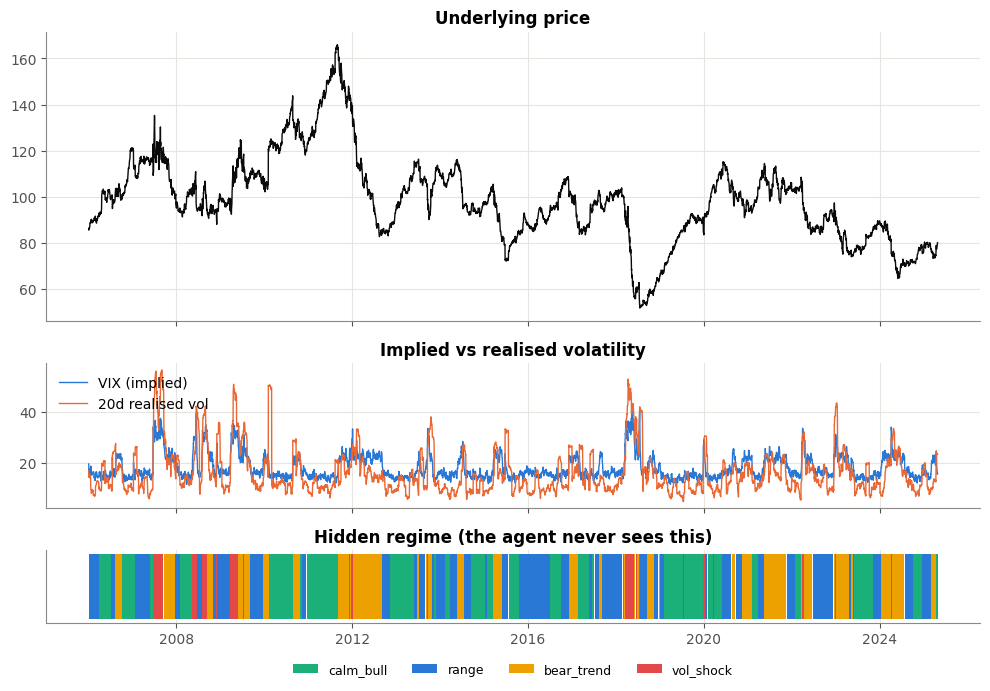

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1, 0.5]})
axes[0].plot(df.index, df.close, color="#0b0b0b", lw=1); axes[0].set_title("Underlying price")
axes[1].plot(df.index, df.vix, color=M.PALETTE[0], lw=1, label="VIX (implied)")
axes[1].plot(df.index, df.rv20, color=M.PALETTE[1], lw=1, label="20d realised vol")
axes[1].legend(loc="upper left"); axes[1].set_title("Implied vs realised volatility")
reg_colors = {"calm_bull": M.PALETTE[2], "range": M.PALETTE[0], "bear_trend": M.PALETTE[3], "vol_shock": M.PALETTE[7]}
for r, c in reg_colors.items():
    axes[2].fill_between(df.index, 0, 1, where=df.regime_name == r, color=c, step="post", label=r, lw=0)
axes[2].set_yticks([]); axes[2].set_title("Hidden regime (the agent never sees this)")
axes[2].legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.4), fontsize=9)
plt.tight_layout(); plt.show()

Notice that implied vol (blue) usually sits **above** realised vol (orange). That's the
volatility risk premium option sellers harvest. In vol shocks, realised shoots above implied,
and short-vol strategies get hurt.

## 0.7 The strategy P&L table: the most important object in this course

For every Monday we compute what each strategy **would have made** if opened at that close and
held to expiry 5 trading days later, net of commissions and slippage. This "counterfactual"
table is exactly what a backtester produces. In Part 9 you'll feed in **your own** version of it.

In [5]:
table = optrl.weekly_pnl_table(market)
print(table.shape, "→ one row per Monday, one column per action")
table.head().round(0)

(1007, 8) → one row per Monday, one column per action


,no_trade,short_straddle,iron_condor,bull_put_spread,bear_call_spread,long_straddle,bull_call_spread,bear_put_spread
date,,,,,,,,
2006-01-02,0.0,200.0,120.0,180.0,180.0,-575.0,64.0,-1065.0
2006-01-09,0.0,-191.0,-2.0,208.0,-662.0,402.0,2185.0,-1071.0
2006-01-16,0.0,226.0,149.0,176.0,176.0,-635.0,-54.0,-1057.0
2006-01-23,0.0,243.0,140.0,220.0,217.0,-683.0,-1071.0,-183.0
2006-01-30,0.0,380.0,147.0,205.0,203.0,-1030.0,-1057.0,-1078.0


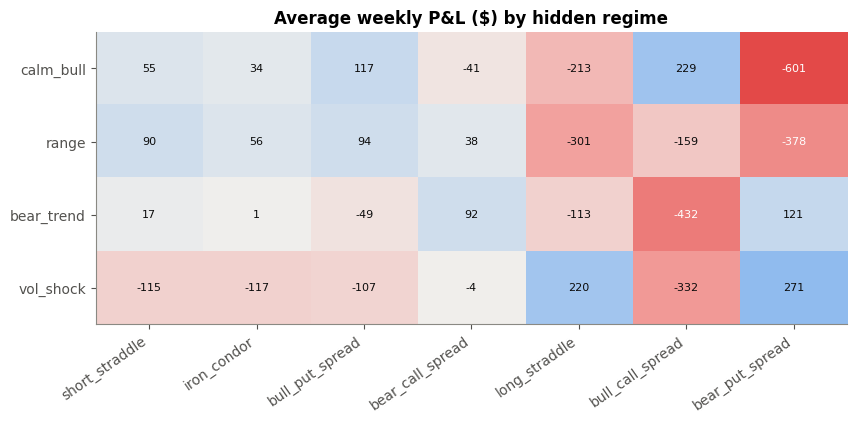

Best strategy per regime:
 regime_name
calm_bull     bull_call_spread
range          bull_put_spread
bear_trend     bear_put_spread
vol_shock      bear_put_spread
dtype: str


In [6]:
regime = df.loc[table.index, "regime_name"]
avg = table.groupby(regime).mean().reindex(["calm_bull", "range", "bear_trend", "vol_shock"])
M.plot_value_heatmap(avg.drop(columns="no_trade"), "Average weekly P&L ($) by hidden regime")
plt.show()
print("Best strategy per regime:\n", avg.idxmax(axis=1))

**Read the heatmap like a trader.** Blue = profitable, red = losing.
* **calm_bull**: bullish trades win. The bull call spread has the highest average, and the
  bull put spread wins more steadily.
* **range**: short-premium trades win (bull put spread, short straddle). Rich IV, little drift.
* **bear_trend**: bearish trades win (bear put spread, bear call spread).
* **vol_shock**: long vol (long straddle) and the bear put spread win. Short vol gets crushed.

Also look at the **size** of the numbers. Premium-selling trades make \$50–120 a week when they
are right. Debit trades make or lose several hundred. That difference in variance will matter a
lot when the agent has to *learn* these numbers from noisy samples.

**No single strategy wins everywhere.** That's the entire reason to build a selector.

## 0.8 The scenario that motivates the course

> *It's Monday. VIX is between 13 and 14. EMA9 < EMA20. What should the agent pick, and why?*

Think like a trader first. VIX 13–14 is **low** implied vol. EMA9 < EMA20 says the
**short-term trend is down**. Is this the start of a bear market, or a dip in a calm bull
market? Low VIX and a calm term structure say "dip". A bear trend usually lifts VIX and
flattens the curve. So a sensible agent should *not* reach for the bear put spread just because
EMA9 < EMA20.

Let's see what the data says. You'll do this yourself in the exercise.

---
### 🛠 Exercise 0.1: query the P&L table for the scenario
Write `scenario_weeks(market, table)` that returns the rows of `table` where, on that Monday,
`vix` is between 13 and 14 **and** `ema9 < ema20`. Then print how many weeks match and the
average P&L of each strategy on those weeks.

*Expected output (roughly):* about 10–20 matching weeks, almost all in the `calm_bull` regime.
The averages are **noisy**: with ~15 samples, one lucky long-straddle week can make it look
like the winner.

In [7]:
def scenario_weeks(market, table):
    # TODO: use market.df.loc[table.index, ...] to build a boolean mask
    return None

res = scenario_weeks(market, table)
print("⏳ not done yet" if res is None else res.mean().round(0))

⏳ not done yet


**Solution**

In [8]:
def scenario_weeks(market, table):
    d = market.df.loc[table.index]
    mask = d.vix.between(13, 14) & (d.ema9 < d.ema20)
    return table[mask]

wk = scenario_weeks(market, table)
print(f"{len(wk)} matching Mondays; regimes:", df.loc[wk.index, "regime_name"].value_counts().to_dict())
print(wk.mean().round(0).sort_values(ascending=False))
print("\nStandard error of each average ($):", (wk.std() / np.sqrt(len(wk))).round(0).to_dict())

14 matching Mondays; regimes: {'calm_bull': 12, 'range': 2}
long_straddle       233.0
bull_call_spread    167.0
no_trade              0.0
bull_put_spread     -34.0
bear_call_spread    -54.0
short_straddle     -124.0
iron_condor        -134.0
bear_put_spread    -219.0
dtype: float64

Standard error of each average ($): {'no_trade': 0.0, 'short_straddle': 125.0, 'iron_condor': 121.0, 'bull_put_spread': 117.0, 'bear_call_spread': 109.0, 'long_straddle': 313.0, 'bull_call_spread': 351.0, 'bear_put_spread': 356.0}


**What this teaches you (the key idea of Part 0).** The standard errors are in the hundreds of
dollars, as big as the averages themselves. **A lookup table of past look-alike weeks is too
noisy to trust.** An agent has to *generalise*: borrow strength from similar situations (low
VIX, contango, mild dip) instead of memorising 15 data points. Parts 3–7 are different ways of
doing exactly that.

### 🛠 Exercise 0.2: implied vs realised
Compute the percentage of days on which `vix > rv20` (options richer than realised). Then
compute the same number within each regime.

*Expected:* roughly three days in four overall. About 80% in calm_bull and range, and far lower
(around 30%) in vol_shock, when realised vol overtakes implied.

In [9]:
# TODO: your code here

**Solution**

In [10]:
rich = df.vix > df.rv20
print(f"Overall: {rich.mean():.0%} of days IV > RV")
print(rich.groupby(df.regime_name).mean().round(2))

Overall: 76% of days IV > RV
regime_name
bear_trend    0.71
calm_bull     0.82
range         0.82
vol_shock     0.30
dtype: float64


## Recap
* RL learns **decisions from consequences**. Supervised learning learns **predictions from answers**.
* Our agent picks 1 of 8 actions (7 strategies + no trade) from market features.
* The P&L table shows **different strategies win in different regimes**. The agent must infer
  the hidden regime from noisy features and generalise, not memorise.

**Next → Part 1:** the vocabulary of RL, with every term mapped onto this problem.